Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 

Lab 1
Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [4]:
y_pred = model.predict(X_test)  # The predicted score is quite close to the actual score
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [5]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


c:\Users\lorah\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


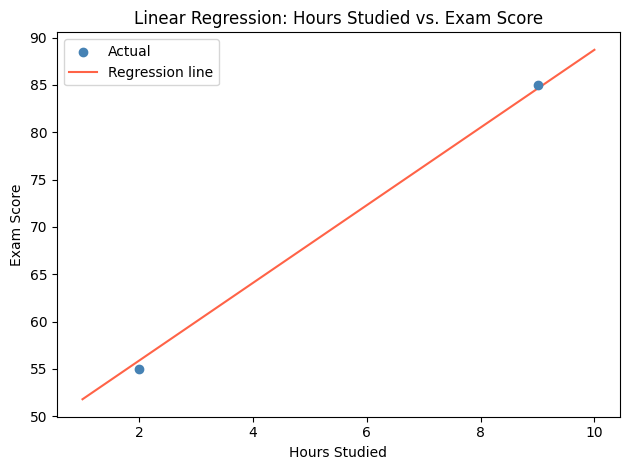

In [6]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
 X['hours_studied'].min(),
 X['hours_studied'].max(),
 100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

Lab 2
Building my own model

In [7]:
#This dataset shows how monthly ad spending relates to monthly revenue.
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000,
                         9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                        12400, 13100, 14200, 15600, 15900, 17200, 18100,
                        19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads


,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [8]:
#Defining x2 and y2

#X2 is my feature (input).
#y2 is my target (output).
#Shapes confirm the data is structured correctly.

X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


In [9]:
#Train/test split

#I’m splitting the data so the model trains on 80% and tests on 20%.
#random_state=42 ensures reproducible result

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)


In [10]:
#training model 2

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print("Model trained successfully.")


Model trained successfully.


In [11]:
#Slope and Intercept

#The slope tells me how much revenue increases for each additional dollar spent on ads.

print(f"Slope: {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

Slope: 1.96
Intercept: 3625.89


Making predictions and evaluating the model

In [12]:
y2_pred = model2.predict(X2_test)
print("Actual:", list(y2_test))
print("Predicted:", list(y2_pred.round(2)))


Actual: [4200, 21500, 19400, 5100]
Predicted: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [13]:
r2_ads = model2.score(X2_test, y2_test)
print(f"R² score: {r2_ads:.3f}")


R² score: 0.998


#The R² score tells me how much of the variation in revenue is explained by ad spend.
A high R² means ad spend is a strong predictor of revenue.
A low R² means other factors influence revenue more.

Visualizing the results

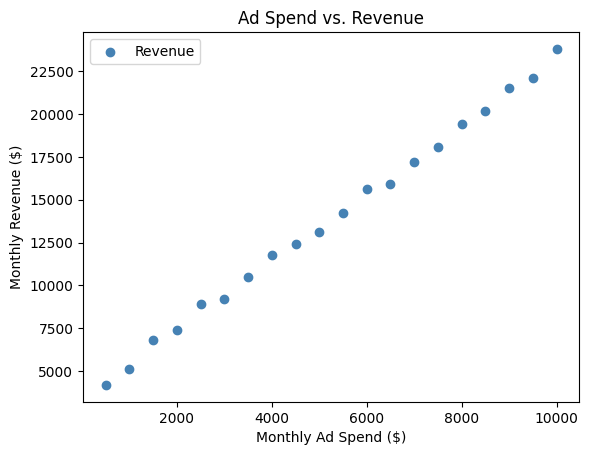

In [24]:
plt.scatter(X2, y2, color='steelblue', label= 'Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()


c:\Users\lorah\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


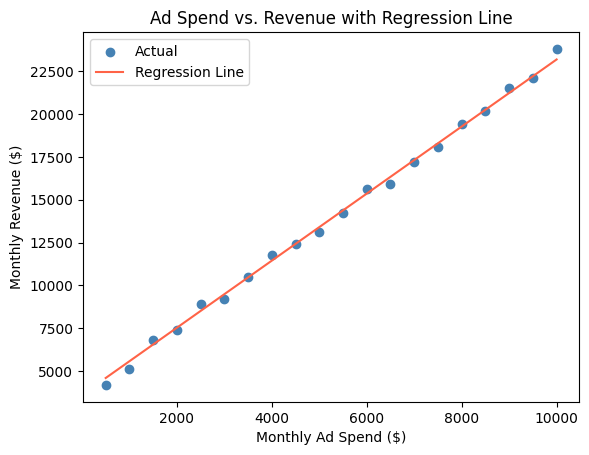

In [15]:
plt.scatter(X2, y2, color='steelblue', label='Actual')

x_range2 = np.linspace(X2.min(), X2.max(), 100).reshape(-1, 1)
y_line2 = model2.predict(x_range2)

plt.plot(x_range2, y_line2, color='tomato', label='Regression Line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue with Regression Line')
plt.legend()
plt.show()


#The regression line fits the data very closely, which matches the high R² score.
This means ad spend is strongly correlated with revenue, and the model is a good fit.

After changing test_size and random_state, I noticed the R² score and predictions changed.
This shows that different splits can affect model performance because the training data changes.